# Phase 3 — Visualization

**Goal of this notebook:** turn Phase 2's numbers into five presentation-ready charts. Each chart has one job, and each gets saved as a PNG in `figures/` for the slides.

| # | Chart | Its one job |
|---|---|---|
| 1 | Histogram of sleep quality | Show what we're predicting and where Low/Med/High cut it |
| 2 | Scatter: stress vs sleep quality | Show the strong negative relationship (*the money chart*) |
| 3 | Three scatters side by side | Prove visually that stress has signal and age/steps don't |
| 4 | Correlation heatmap | All relationships in one image |
| 5 | Bar chart: avg quality per stress level | The cleanest slide version of the stress effect |

**Design rules we follow:** every axis labeled · colorblind-safe colors (no red/green pairs carrying meaning) · no truncated axes · minimal grid · a one-line takeaway under each chart. Correlations run negative→positive, so the heatmap uses a **diverging** blue↔red palette with a neutral gray midpoint — not a rainbow.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap

df = pd.read_csv("../sleep_health_dataset.csv")

# --- palette (colorblind-safe, validated) ---
BLUE      = "#2a78d6"   # primary hue for marks
BLUE_DARK = "#104281"   # trend lines / emphasis
BLUE_LIGHT= "#9ec5f4"   # de-emphasized marks
RED       = "#e34948"   # negative pole of the diverging heatmap only
GRAY_MID  = "#f0efec"   # neutral midpoint (correlation = 0)
INK       = "#0b0b0b"; INK_SOFT = "#52514e"

# --- one style for every chart: recessive grid, no chart junk ---
mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": "#e6e4de", "grid.linewidth": 0.6,
    "axes.axisbelow": True,          # grid stays BEHIND the data
    "axes.labelcolor": INK, "axes.edgecolor": INK_SOFT,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlecolor": INK,
    "font.size": 11,
})

print("loaded:", df.shape)

loaded: (100000, 32)


## Chart 1 — What are we predicting?

A histogram of the target, `sleep_quality_score`. The dashed lines mark where we'll cut the score into **Low (≤4) / Medium (5–6) / High (≥7)** buckets for the Random Forest in Phase 4 — so the audience sees both the score *and* the classes in one image.

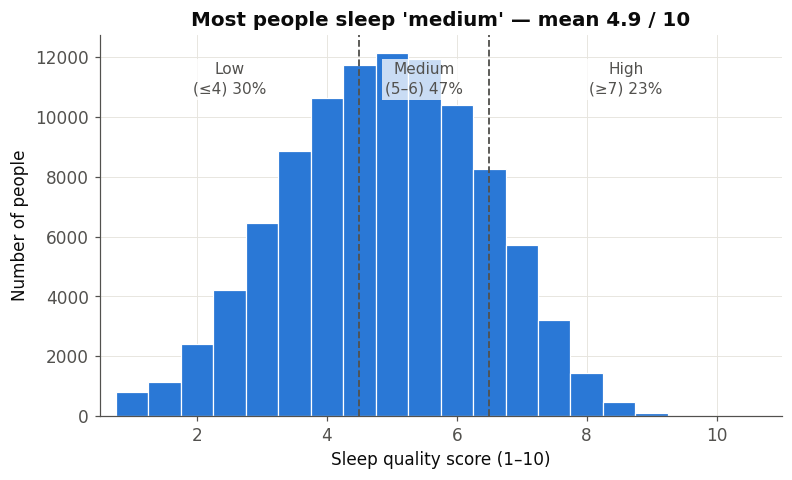

In [2]:
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.hist(df["sleep_quality_score"], bins=np.arange(0.75, 10.76, 0.5),
        color=BLUE, edgecolor="white", linewidth=0.8)

for cut in (4.5, 6.5):
    ax.axvline(cut, color=INK_SOFT, linestyle="--", linewidth=1.2)
for x, label in ((2.5, "Low\n(≤4) 30%"), (5.5, "Medium\n(5–6) 47%"), (8.6, "High\n(≥7) 23%")):
    ax.text(x, ax.get_ylim()[1]*0.93, label, ha="center", va="top",
            color=INK_SOFT, fontsize=10, linespacing=1.4,
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=2))

ax.set_xlabel("Sleep quality score (1–10)")
ax.set_ylabel("Number of people")
ax.set_title("Most people sleep 'medium' — mean 4.9 / 10")
ax.set_xlim(0.5, 11)
fig.savefig("../figures/01_sleep_quality_histogram.png")
plt.show()

**Takeaway:** sleep quality is roughly bell-shaped around 4.9, and our three classes are unbalanced (30 / 47 / 23%) — which is exactly why Phase 4 stratifies its splits and compares against the 47% "always guess Medium" baseline.

## Chart 2 — The money chart: stress vs sleep quality

100,000 points would render as a solid blob (*overplotting*), so we plot a random sample of 3,000 with transparency — enough to show the shape, few enough to see it. The dark line is the average sleep quality at each stress level: the trend itself.

Both variables only take whole/half values, so points would stack exactly on top of each other; a tiny random *jitter* spreads them out so density is visible. (Jitter changes nothing about the data — only where dots sit on screen.)

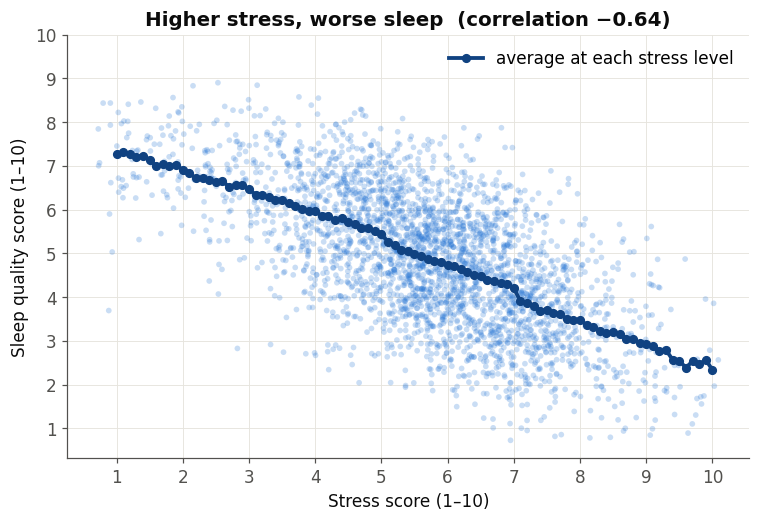

In [3]:
rng = np.random.default_rng(117)
sample = df.sample(3000, random_state=117)

def jitter(values, width=0.28):
    return values + rng.uniform(-width, width, len(values))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(jitter(sample["stress_score"]), jitter(sample["sleep_quality_score"]),
           s=14, alpha=0.25, color=BLUE, edgecolors="none")

trend = df.groupby("stress_score")["sleep_quality_score"].mean()
ax.plot(trend.index, trend.values, color=BLUE_DARK, linewidth=2.5, marker="o",
        markersize=5, label="average at each stress level")

ax.set_xlabel("Stress score (1–10)")
ax.set_ylabel("Sleep quality score (1–10)")
ax.set_title("Higher stress, worse sleep  (correlation −0.64)")
ax.legend(frameon=False, loc="upper right")
ax.set_xticks(range(1, 11)); ax.set_yticks(range(1, 11))
fig.savefig("../figures/02_stress_vs_quality.png")
plt.show()

**Takeaway:** the cloud slopes clearly downward — people at stress 9–10 average ~3.5/10 sleep quality while people at stress 1–2 average ~7/10. This one relationship is what our models will learn.

## Chart 3 — The comparison that proves the finding

Same y-axis, same sampling, three predictors side by side. Stress slopes; age and steps are flat clouds. This is the visual proof of Phase 2's correlation table — no statistics background needed to read it.

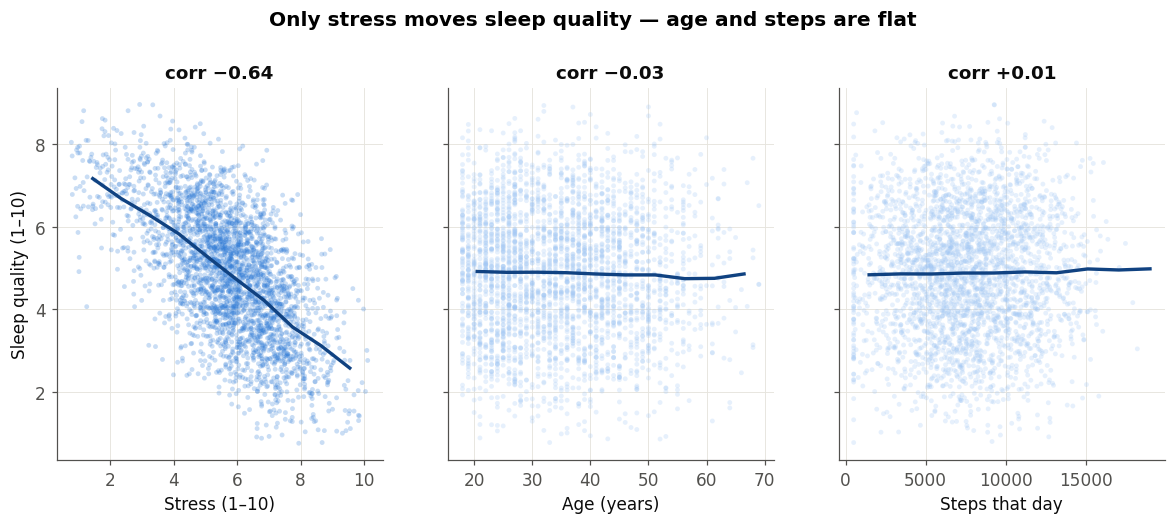

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.4), sharey=True)
panels = [
    ("stress_score",   "Stress (1–10)",        "corr −0.64", True),
    ("age",            "Age (years)",           "corr −0.03", False),
    ("steps_that_day", "Steps that day",        "corr +0.01", False),
]
for ax, (col, xlabel, corr_label, has_signal) in zip(axes, panels):
    x = jitter(sample[col]) if col == "stress_score" else sample[col]
    color = BLUE if has_signal else BLUE_LIGHT
    ax.scatter(x, jitter(sample["sleep_quality_score"]),
               s=10, alpha=0.25, color=color, edgecolors="none")
    # average-line per binned x, to make flatness (or slope) unmistakable
    bins = pd.cut(df[col], 10)
    line = df.groupby(bins, observed=True)["sleep_quality_score"].mean()
    centers = [iv.mid for iv in line.index]
    ax.plot(centers, line.values, color=BLUE_DARK, linewidth=2.2)
    ax.set_xlabel(xlabel)
    ax.set_title(corr_label, fontsize=12)
axes[0].set_ylabel("Sleep quality (1–10)")
fig.suptitle("Only stress moves sleep quality — age and steps are flat",
             fontweight="bold", y=1.04)
fig.savefig("../figures/03_signal_vs_no_signal.png")
plt.show()

**Takeaway:** the dark average-line falls ~3.5 points across the stress range but stays flat across age and steps. If a model later claims steps is its most important feature, this picture is the rebuttal.

*(Design note: the flat panels are drawn in a lighter blue on purpose — the eye should go to the panel with signal.)*

## Chart 4 — Correlation heatmap

Every pairwise correlation among our variables in one image. Correlations run **negative → zero → positive**, i.e. the data has *polarity* — so the correct palette is a **diverging** one: red for negative, gray for zero, blue for positive. (A rainbow palette here would imply order where there is none.)

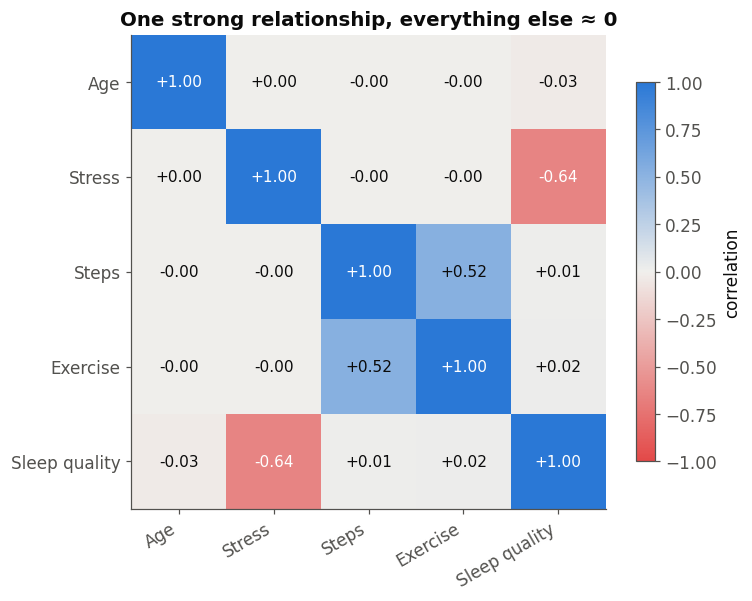

In [5]:
cols = ["age", "stress_score", "steps_that_day", "exercise_day", "sleep_quality_score"]
labels = ["Age", "Stress", "Steps", "Exercise", "Sleep quality"]
corr = df[cols].corr()

diverging = LinearSegmentedColormap.from_list("rg", [RED, GRAY_MID, BLUE])

fig, ax = plt.subplots(figsize=(7, 5.6))
im = ax.imshow(corr, cmap=diverging, vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=30, ha="right")
ax.set_yticks(range(len(labels)), labels)
ax.grid(False)

for i in range(len(labels)):
    for j in range(len(labels)):
        v = corr.iloc[i, j]
        ax.text(j, i, f"{v:+.2f}", ha="center", va="center", fontsize=10,
                color="white" if abs(v) > 0.55 else INK)

fig.colorbar(im, ax=ax, shrink=0.8, label="correlation")
ax.set_title("One strong relationship, everything else ≈ 0")
fig.savefig("../figures/04_correlation_heatmap.png")
plt.show()

**Takeaway:** the only saturated cell involving *sleep quality* is stress (−0.64) — everything in its row/column is gray. Bonus observation the heatmap surfaced: **steps and exercise correlate +0.52 with each other** (people who exercise also walk more — sensible), yet *neither* relates to sleep quality. Stress is uncorrelated with the other predictors, so the regression's stress coefficient is clean of multicollinearity.

## Chart 5 — The slide version: average sleep quality at each stress level

The same story as chart 2, reduced to ten bars — the cleanest version for a presentation. Bars start at 0 (never truncate a bar axis), and each carries its value so no one has to squint at the y-axis.

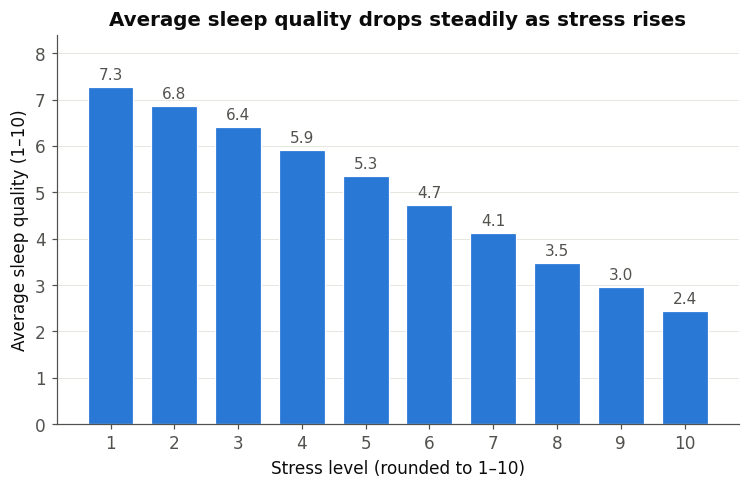

In [6]:
# stress_score is continuous (e.g. 4.4), so round to integer levels first —
# otherwise we'd get ~90 skinny bars instead of 10
stress_level = df["stress_score"].round().clip(1, 10).astype(int)
avg = df.groupby(stress_level)["sleep_quality_score"].mean()

fig, ax = plt.subplots(figsize=(8, 4.6))
bars = ax.bar(avg.index, avg.values, color=BLUE, width=0.72,
              edgecolor="white", linewidth=0.8)
ax.bar_label(bars, fmt="%.1f", padding=3, fontsize=10, color=INK_SOFT)

ax.set_xlabel("Stress level (rounded to 1–10)")
ax.set_ylabel("Average sleep quality (1–10)")
ax.set_title("Average sleep quality drops steadily as stress rises")
ax.set_xticks(range(1, 11))
ax.set_ylim(0, 8.4)
ax.grid(axis="x", visible=False)
fig.savefig("../figures/05_avg_quality_by_stress.png")
plt.show()

**Takeaway:** from stress 1 to stress 10, average sleep quality falls from ~7.1 to ~3.4 — a steady, monotonic decline of nearly 4 points. No cherry-picking, no axis tricks: the effect is simply that large.

---

## Files produced

| File | Use on slide |
|---|---|
| `figures/01_sleep_quality_histogram.png` | "What we predict" + class split |
| `figures/02_stress_vs_quality.png` | The core relationship |
| `figures/03_signal_vs_no_signal.png` | Proof that only stress matters |
| `figures/04_correlation_heatmap.png` | All relationships at once |
| `figures/05_avg_quality_by_stress.png` | Cleanest slide version |

**Next (Phase 4):** train both models — and check them against these pictures.